## CM32024 / CM52037

## Assessment 2, Part A

# GP Evidence Maximisation & Sparse Variational Gaussian Processes


**Total Marks 35 (35% of overall unit grade).**

*Submission deadline: 8pm, Wednesday May 6. Please submit all your files in Moodle.*


**This is Part A of the second assessment** and represents 35% of the overall unit grade. The accompanying Part B (an extension to Bayesian Optimisation), will be worth 15%.

Part A is focused on *Sparse Variational Gaussian Processes*. It involves implementing and assessing sparse GPs on a regression dataset and a classification dataset, using variational inference.

## Submission & Marking

For this part of the coursework there are a number of places in this notebook where you are expected to enter your own code.
Every place you have to add code is  indicated by:

`#### **** YOUR CODE HERE **** ####`

Full instructions as to what is expected should be found above all the relevant cells.

If you are asked to give a written / mathematical response, this will be indicated in a markdown cell as

# \#\#\# \*\*\*\* YOUR ANSWER HERE \*\*\*\* \#\#\#

**Please submit your completed workbook using Moodle**.
The workbook you submit must be an `.ipynb` file, which is saved into the
directory you're running Jupyter; alternatively you can download it from the menu above using
`File -> Download`. Remember to save your work regularly
("Save Notebook" in the File menu, the icon of a floppy disk, or Ctrl-S);
**the version you submit should have all code blocks showing the results (if any)
of execution below them**.

### Important!

**You should take care to avoid any suggestion of plagiarism in your submission.**
There is helpful information on "Academic Integrity" and, specifically, how to avoid plagiarism
on the University website: https://www.bath.ac.uk/library/help/infoguides/plagiarism.html

For this coursework, **you may use library code from specific sources only**:
- `numpy` and `scipy`, or more likely `jax.numpy` and `jax.scipy` for core programming of linear algebra / mathematics.
- `optax` for using the Adam optimiser to optimise your variational parameters.
- `sklearn` for k-means clustering and the `make_moons` dataset.
- `matplotlib` and / or `seaborn` are recommended for plotting, though this is not a strict requirement.

If you wish to use any alternative libraries, you are welcome to request this via the *Moodle* discussion forum. (All reasonable requests will be considered.)

Note that **the use of Generative AI is not permitted**.

# Assessment 2, Part A: Sparse Variational Gaussian Processes

**Task 1**: Type-II Maximum Likelihood for Full-Rank GPs and Fitting to Subsets of Data (6 marks)

**Task 2** Sparse Variational Gaussian Process Regression (24 Marks)

**Task 3** Sparse Variational Gaussian Process Classification (5 Marks)

## Setup

### Imports

In [1]:
import numpy as np # In case we need to fall back on NumPy
import matplotlib.pyplot as plt

# JAX including Optax for optimisation
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax

# Scikit-learn for KMeans clustering
from sklearn.cluster import KMeans

# For timing methods (not assessed, but useful)
import time

### Generate Data. Do not modify this code.


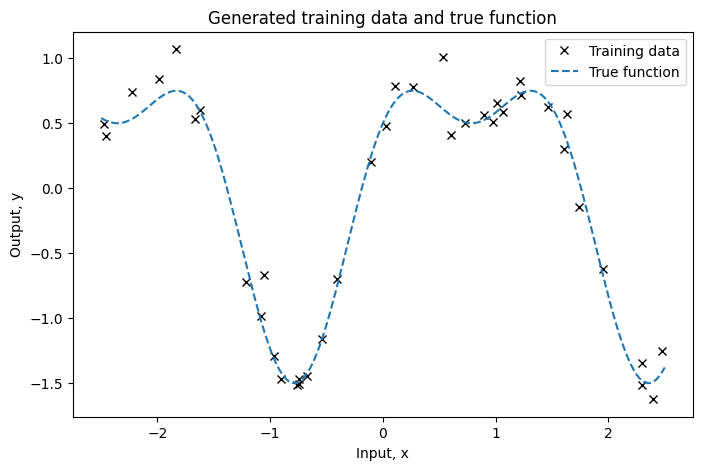

In [2]:
# True function
def f_true(x):
    return np.sin(2.0 * x) + 0.5 * np.cos(4.0 * x)

def generate_training_data(rng_key, true_noise_var, N_train):
    rng_key, rng_subkey = jax.random.split(rng_key)
    # Generate some input values
    X_train = jnp.sort(jax.random.uniform(rng_subkey, shape=(N_train,), minval=-2.5, maxval=2.5))

    # Observations are function plus Gaussian noise
    rng_key, rng_subkey = jax.random.split(rng_key)
    y_train = f_true(X_train) + jnp.sqrt(true_noise_var) * jax.random.normal(rng_subkey, shape=(N_train,))

    return X_train, y_train

rng_key = jax.random.PRNGKey(0) # Original random key

# Data constants
N_train = 40
true_noise_var = 0.15**2 # I.e. 0.0225

# JAX does not keep a global random state like NumPy. It is purely functional.
# In JAX, we must always split the random key when we need to use it.
# key gets overwritten by the new "main" key, and we use the subkey to actually do our random operation.
rng_key, rng_subkey = jax.random.split(rng_key)

X_train, y_train = generate_training_data(rng_subkey, true_noise_var, N_train)

# Define grid data for plotting true function (and later predicted functions)
X_grid = jnp.linspace(-2.5, 2.5, 200)
f_grid = f_true(X_grid)

# Plot the data
plt.figure(figsize=(8, 5))
plt.plot(X_train, y_train, 'kx', label='Training data')
plt.plot(X_grid, f_grid, '--', label='True function')
plt.xlabel('Input, x')
plt.ylabel('Output, y')
plt.title('Generated training data and true function')
plt.legend()
plt.show()

### Full rank GP Fit
Since we already had a lab on fitting full-rank GPs (without tuning hyperparameters), we will not repeat that exercise here, and instead provide a short implementation of the full-rank GP regression posterior below.

We have intentionally initialised the hyperparameters poorly, so that you can see the effect of optimising them in Task 1. Feel free to play around with the hyperparameters manually to see how they affect the fit before you start Task 1.

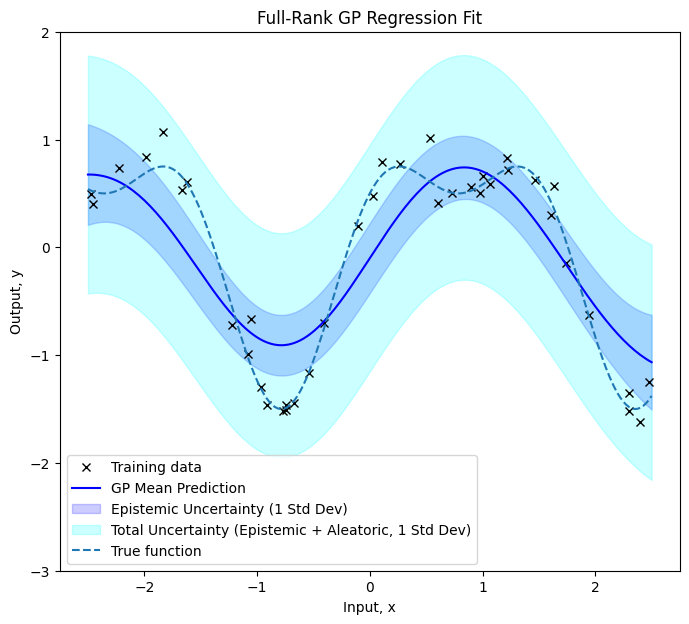

In [3]:
# This code uses broadcasting to compute the RBF kernel matrix, for multivariate inputs, and also has a diagonal-only option.
def rbf_kernel(x1, x2, lengthscale, variance, diag=False):
    # If you provide a flat vector for 1d inputs, reshape to general 2D format (N, D).
    if x1.ndim == 1:
        x1 = x1.reshape(-1, 1)
        x2 = x2.reshape(-1, 1)
    if diag:
        # Still use the distances (in case x1 and x2 are different but equal length datasets and we want the diagonal) but only return the diagonal of the kernel matrix.
        dist_sq_diag = jnp.sum((x1 - x2) ** 2, axis=-1)
        return variance * jnp.exp(-0.5 * dist_sq_diag / (lengthscale**2))
    else:
        # Note that the extra dimension that we sum over is redundant because we only have 1D inputs.
        # But we keep the code general for potential multi-dimensional inputs.
        dist_sq = jnp.sum((x1[:, None, :] - x2[None, :, :]) ** 2, axis=-1)
        return variance * jnp.exp(-0.5 * dist_sq / (lengthscale**2))

# Cholesky with jitter
def stable_cholesky(K, jitter=1e-5):
    return jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))

# Full-rank GP regression posterior
def exact_gp_posterior(X_train, y_train, X_test, lengthscale, variance, noise_var):
    N = X_train.shape[0]
    K_xx_noisy = rbf_kernel(X_train, X_train, lengthscale, variance) + noise_var * jnp.eye(N)
    K_xs = rbf_kernel(X_train, X_test, lengthscale, variance)
    # We don't both computing covariances for test predictions (we'd still need it for sampling functions e.g. across a grid, but we only compute predictions in this code)
    K_ss = rbf_kernel(X_test, X_test, lengthscale, variance) 
    
    L = stable_cholesky(K_xx_noisy)
    K_xx_inv_y = jsp.linalg.cho_solve((L, True), y_train) # K_xx^{-1} y via Cholesky
    mu = K_xs.T @ K_xx_inv_y # K_sx K_xx^{-1} y
    
    # Want to compute: cov = K_ss - K_sx K_xx^{-1} K_xs
    # Equivalent to cov = K_ss - K_sx (L^{-T} L^{-1}) K_xs for K_xx = L L^T
    K_sx_L_invT = jsp.linalg.solve_triangular(L, K_xs, lower=True).T # K_sx L^{-T}
    cov = K_ss - K_sx_L_invT @ K_sx_L_invT.T # K_ss - K_sx L^{-T} L^{-1} K_xs
    
    return mu, cov

# Plot full-rank GP fit
# Default hyperparameters: lengthscale=1, variance=1**2, noise_var=1**2
lengthscale = 1
variance = 1**2
noise_var = 1**2

def plot_exact_gp_fit(X_train, y_train, X_grid, f_grid, lengthscale, variance, noise_var, training_data_opacity=1.0):
    mu_f, cov_f = exact_gp_posterior(X_train, y_train, X_grid, lengthscale, variance, noise_var)
    epistemic_std_f = jnp.sqrt(jnp.diag(cov_f))
    aleatoric_std = jnp.sqrt(noise_var)
    plt.figure(figsize=(8, 7))
    plt.plot(X_train, y_train, 'kx', label='Training data', alpha=training_data_opacity)
    plt.plot(X_grid, mu_f, 'b', label='GP Mean Prediction')
    plt.fill_between(X_grid, mu_f - epistemic_std_f, mu_f + epistemic_std_f, color='blue', alpha=0.2, label='Epistemic Uncertainty (1 Std Dev)')
    plt.fill_between(X_grid, mu_f - jnp.sqrt(epistemic_std_f**2 + aleatoric_std**2), mu_f + jnp.sqrt(epistemic_std_f**2 + aleatoric_std**2), color='cyan', alpha=0.2, label='Total Uncertainty (Epistemic + Aleatoric, 1 Std Dev)')
    plt.plot(X_grid, f_grid, '--', label='True function')
    plt.xlabel('Input, x')
    plt.ylabel('Output, y')
    plt.title('Full-Rank GP Regression Fit')
    plt.legend(loc ='lower left')
    plt.ylim(-3, 2)
    plt.show()

plot_exact_gp_fit(X_train, y_train, X_grid, f_grid, lengthscale, variance, noise_var)

# Task 1: Type-II Maximum Likelihood for Full-Rank GPs and Fitting to Subsets of Data
**6 marks for this task in total.**

For a Gaussian process regression model, that is a Gaussian process prior over functions $p(\mathbf f) = \mathcal{N}(\mathbf{f}; \mathbf{0}, \mathbf{K})$ (**note that throughout this coursework we will assume a zero-mean Gaussian prior**) with a Gaussian likelihood $p(\mathbf y | \mathbf f) = \mathcal N(\mathbf y; \mathbf f, \sigma_\text{noise} \mathbf I)$, simple "adding Gaussians" identities tell us that the marginal distribution over $\mathbf y$ (for fixed values of any hyperparameters e.g. kernel hyperparameters, we are only marginalising over $\mathbf f$ here) is also Gaussian:
$$p(\mathbf y; \sigma_\text{noise}, \sigma_\text{RBF}, \ell) = \mathcal N(\mathbf y; \mathbf 0, \mathbf K + \sigma^2_\text{noise} \mathbf I).$$
The log marignal likelihood (or log "evidence") therefore has a very simple closed-form expression. We are going to use this to optimise our hyperparameters `lengthscale`, `variance`, and `noise_variance` by Type-II Maximum Likelihood, specifically using gradient ascent on the log marginal likelihood, with JAX's automatic differentiation capabilities, and the Adam optimiser from the `optax` library. Note that for such a low-dimensional function, we would usually use a more traditional optimiser like BFGS, as used in `jax.scipy.optimize.minimize`, but since we will be using minibatching later in the sparse GP tasks, we will demonstrate how to use the more flexible Optax library here.

### JAX and Optax Guidance
We provide some guidance on how to use JAX's autodiff with Optax below, since these frameworks can be confusing if you're unfamiliar with them.

Suppose we are maximising the simple function $f(x) = -c(x-b)^2$ with respect to $x$. We would define this function in JAX as:

Text(0.5, 1.0, 'Quadratic Function and Current Guess')

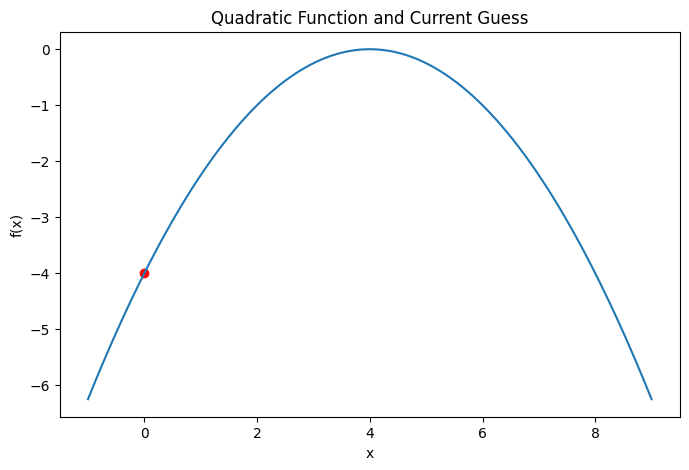

In [4]:
def quadratic_f(x, b, c):
    return -c * (x - b)**2

current_x_guess = jnp.array(0.0) # Initial guess for the maximum of the quadratic function

# Plot the quadratic function for some parameters
plt.figure(figsize=(8, 5))
plt.plot(jnp.linspace(-1, 9, 200), quadratic_f(jnp.linspace(-1, 9, 200), b=4, c=0.25), label='Quadratic Function')
plt.scatter(current_x_guess, quadratic_f(current_x_guess, b=4, c=0.25), color='red', label='Current Guess')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Quadratic Function and Current Guess')

Starting at `current_x_guess` we are going to use gradient ascent to find the maximum of this function, which is at $x=b$. We will use Optax, JAX's optimisation library, to do this. Note we need to negate the function because Optax is designed for minimisation, but we want to maximise.

A standard Optax loop would look something like this:

Iteration 1, x_guess: 0.2000, f(x_guess): -4.0000
Iteration 2, x_guess: 0.3900, f(x_guess): -3.6100
Iteration 3, x_guess: 0.5705, f(x_guess): -3.2580
Iteration 4, x_guess: 0.7420, f(x_guess): -2.9404
Iteration 5, x_guess: 0.9049, f(x_guess): -2.6537
Iteration 6, x_guess: 1.0596, f(x_guess): -2.3949
Iteration 7, x_guess: 1.2067, f(x_guess): -2.1614
Iteration 8, x_guess: 1.3463, f(x_guess): -1.9507
Iteration 9, x_guess: 1.4790, f(x_guess): -1.7605
Iteration 10, x_guess: 1.6051, f(x_guess): -1.5889
Iteration 11, x_guess: 1.7248, f(x_guess): -1.4339
Iteration 12, x_guess: 1.8386, f(x_guess): -1.2941
Iteration 13, x_guess: 1.9466, f(x_guess): -1.1680
Iteration 14, x_guess: 2.0493, f(x_guess): -1.0541
Iteration 15, x_guess: 2.1468, f(x_guess): -0.9513
Iteration 16, x_guess: 2.2395, f(x_guess): -0.8586
Iteration 17, x_guess: 2.3275, f(x_guess): -0.7748
Iteration 18, x_guess: 2.4111, f(x_guess): -0.6993
Iteration 19, x_guess: 2.4906, f(x_guess): -0.6311
Iteration 20, x_guess: 2.5661, f(x_guess

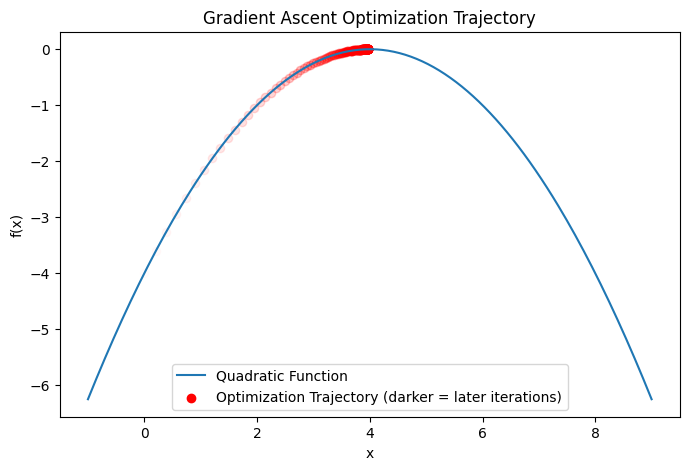

In [5]:
# Create the optimiser object and initialise its state (some optimisers have internal state, e.g. Adam tracks moving averages of gradients).
opt = optax.sgd(learning_rate=0.1)
opt_state = opt.init(current_x_guess)

# When we have multiple parameters to optimise, we will want to store them in a dictionary, which JAX and Optax functions such as grad, opt.update, etc. can automatically handle.
params = {
    "x" : current_x_guess
}

# Hence we will need to modify our function to take in the parameters as a dictionary, and extract the relevant parameter(s) from it.
def dict_quadratic_f(params, b, c):
    x = params["x"]
    return -c * (x - b)**2

from functools import partial

def step(params, opt_state):
    # Fix b and c, returning a function of x only
    # Remember to negate because we want to maximise, but optax minimises by default.
    # obj_func = partial(dict_quadratic_f, b=4, c=0.25)
    obj_func = lambda params: -dict_quadratic_f(params, b=4, c=0.25) # Negate to maximise instead of minimise

    # Compute the value and gradient of the objective function at the current guess
    value, grad = jax.value_and_grad(obj_func)(params)

    # Use our optimiser to compute the next update / step, and return the new optimiser state 
    update, opt_state = opt.update(grad, opt_state)

    # Apply the update to our current guess to get the new guess
    new_x_guess = optax.apply_updates(params, update)

    return new_x_guess, opt_state, value

# Run the optimisation loop for a few iterations
quadratic_example_num_iters = 100

def quadratic_example_training_loop(num_iters, params, opt_state):
    x_guesses = [params["x"]] # The value returned is always for the guess input, whilst the guess returned is after the update, so we need to store the initial guess before the loop
    values = []
    for i in range(num_iters):
        params, opt_state, value = step(params, opt_state)
        x_guesses.append(params["x"])
        values.append(value)
        print(f"Iteration {i+1}, x_guess: {params['x']:.4f}, f(x_guess): {-value:.4f}") # Remember to negate value to get the actual function value
    values.append(-dict_quadratic_f(params, b=4, c=0.25)) # Add the final value for the last guess
    return x_guesses, values

x_guesses, values = quadratic_example_training_loop(quadratic_example_num_iters, params, opt_state)

# Plot the optimisation trajectory, with darker points for later iterations
def plot_quadratic_optimization_trajectory(x_guesses, values, num_iters):
    plt.figure(figsize=(8, 5))
    plt.plot(jnp.linspace(-1, 9, 200), quadratic_f(jnp.linspace(-1, 9, 200), b=4, c=0.25), label='Quadratic Function')
    for i in range(num_iters):
        # -values because we negated the function to maximise instead of minimise
        plt.scatter(x_guesses[i], -values[i], color='red', alpha=(i+1)/num_iters, label='Optimization Trajectory (darker = later iterations)' if i == num_iters - 1 else "")
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Gradient Ascent Optimization Trajectory')
    plt.legend()

plot_quadratic_optimization_trajectory(x_guesses, values, quadratic_example_num_iters)


For more complicated (and high dimensional) optimisation problems, it is sometimes helpful to use the Adam optimiser over SGD (plain-old gradient descent), since it often converges faster, with less fiddling with the learning rate (though the benefit is not apparent for this simple 1D problem).

Iteration 1, x_guess: 0.1000, f(x_guess): -4.0000
Iteration 2, x_guess: 0.1999, f(x_guess): -3.8025
Iteration 3, x_guess: 0.2997, f(x_guess): -3.6101
Iteration 4, x_guess: 0.3993, f(x_guess): -3.4230
Iteration 5, x_guess: 0.4987, f(x_guess): -3.2412
Iteration 6, x_guess: 0.5978, f(x_guess): -3.0647
Iteration 7, x_guess: 0.6966, f(x_guess): -2.8937
Iteration 8, x_guess: 0.7949, f(x_guess): -2.7282
Iteration 9, x_guess: 0.8928, f(x_guess): -2.5682
Iteration 10, x_guess: 0.9901, f(x_guess): -2.4137
Iteration 11, x_guess: 1.0868, f(x_guess): -2.2649
Iteration 12, x_guess: 1.1829, f(x_guess): -2.1217
Iteration 13, x_guess: 1.2782, f(x_guess): -1.9841
Iteration 14, x_guess: 1.3728, f(x_guess): -1.8520
Iteration 15, x_guess: 1.4664, f(x_guess): -1.7256
Iteration 16, x_guess: 1.5592, f(x_guess): -1.6047
Iteration 17, x_guess: 1.6510, f(x_guess): -1.4894
Iteration 18, x_guess: 1.7417, f(x_guess): -1.3795
Iteration 19, x_guess: 1.8312, f(x_guess): -1.2750
Iteration 20, x_guess: 1.9196, f(x_guess

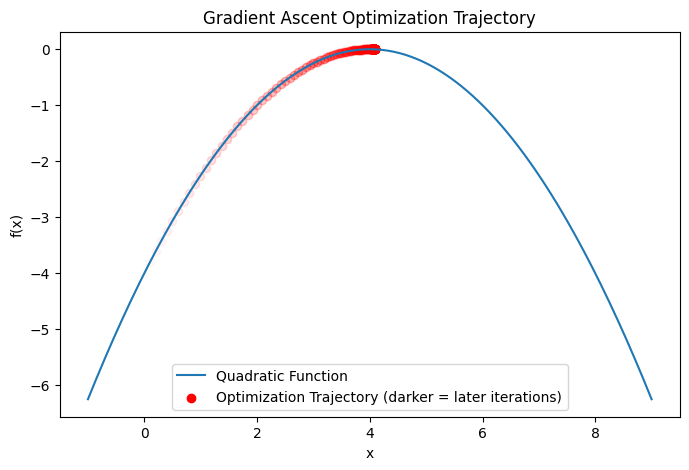

In [6]:
opt = optax.adam(learning_rate=0.1)
opt_state = opt.init(params)

# Reset the parameters to the initial guess
params = {
    "x" : jnp.array(0.0)
}

x_guesses, values = quadratic_example_training_loop(quadratic_example_num_iters, params, opt_state)

plot_quadratic_optimization_trajectory(x_guesses, values, quadratic_example_num_iters)

## <font color="red"> Task 1a </font>
<font color="red"> *4 marks overall* </font>

#### <font color="red"> Implement the log marginal likelihood of the Gaussian process regression model (1 mark) </font>

In [7]:
def gp_log_marginal_likelihood(X_train, y_train, lengthscale, variance, noise_var):
    N = X_train.shape[0]

    # Noisy kernel matrix: K(X,X) + σ²_noise * I
    K_noisy = rbf_kernel(X_train, X_train, lengthscale, variance) + noise_var * jnp.eye(N)

    # Cholesky decomposition for numerical stability: K_noisy = L L^T
    L = stable_cholesky(K_noisy)

    # Log-determinant via Cholesky: log|K_noisy| = 2 * Σ log(L_ii)
    log_det = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))

    # Data-fit term: y^T K_noisy^{-1} y, solved via back-substitution through L
    K_inv_y = jsp.linalg.cho_solve((L, True), y_train)
    data_fit = y_train @ K_inv_y

    # LML = -½ y^T K^{-1} y  -  ½ log|K|  -  N/2 log 2π
    lml = -0.5 * data_fit - 0.5 * log_det - 0.5 * N * jnp.log(2 * jnp.pi)
    return lml

#### <font color="red"> Use Optax to maximise the log marginal likelihood with respect to the hyperparameters (3 marks) </font>
Remember: All of these hyperparameters take strictly positive values, but Optax only does unconstrained optimisation, so you will need to use an appropriate transformation.
- Plot the MLL (y-axis) vs training iteration (x-axis)
- Plot the three hyperparameters (y-axis) vs training iteration (x-axis)
- Plot the resulting GP fit

You may also wish to print the final values of the hyperparameters (and check your learned noise variance against the true noise variance we used to generate the data) though this is not required.

You may need to play around with the learning rate and number of iterations to ensure good convergence. You hyperparameters should all be initialised at 1.0, as above.

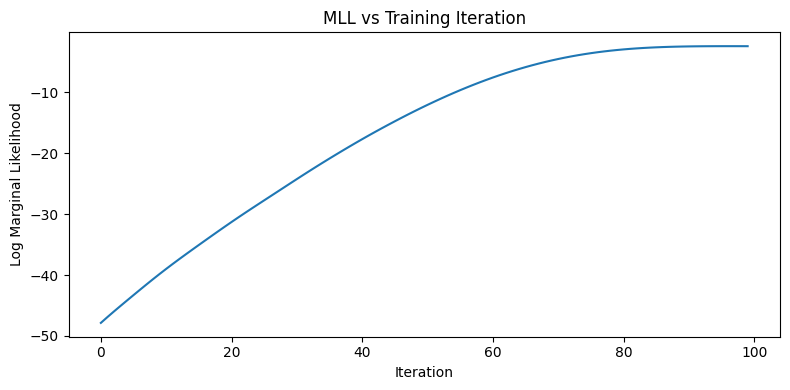

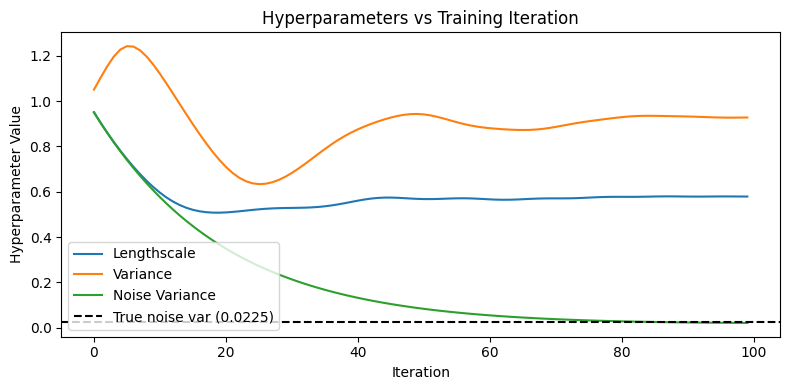

Final lengthscale: 0.5789
Final variance:    0.9281
Final noise var:   0.0207  (true: 0.0225)


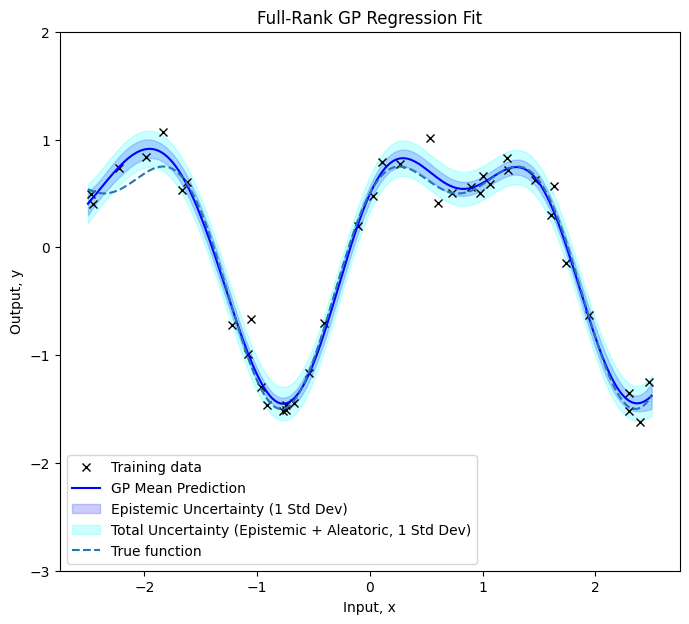

In [8]:
params = {
    "log_lengthscale": jnp.array(0.0),
    "log_variance":    jnp.array(0.0),
    "log_noise_var":   jnp.array(0.0),
}

learning_rate = 0.05
num_iters = 100
opt = optax.adam(learning_rate=learning_rate)
opt_state = opt.init(params)

# Negate the LML because Optax minimises
def neg_lml(params):
    ls  = jnp.exp(params["log_lengthscale"])
    var = jnp.exp(params["log_variance"])
    nv  = jnp.exp(params["log_noise_var"])
    return -gp_log_marginal_likelihood(X_train, y_train, ls, var, nv)

def mll_step(params, opt_state):
    value, grad = jax.value_and_grad(neg_lml)(params)
    updates, opt_state = opt.update(grad, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, value

mll_history         = []
lengthscale_history = []
variance_history    = []
noise_var_history   = []

for i in range(num_iters):
    params, opt_state, neg_val = mll_step(params, opt_state)
    mll_history.append(float(-neg_val))
    lengthscale_history.append(float(jnp.exp(params["log_lengthscale"])))
    variance_history.append(float(jnp.exp(params["log_variance"])))
    noise_var_history.append(float(jnp.exp(params["log_noise_var"])))

# Plot 1: MLL vs iteration
plt.figure(figsize=(8, 4))
plt.plot(mll_history)
plt.xlabel('Iteration')
plt.ylabel('Log Marginal Likelihood')
plt.title('MLL vs Training Iteration')
plt.tight_layout()
plt.show()

# Plot 2: Hyperparameters vs iteration
plt.figure(figsize=(8, 4))
plt.plot(lengthscale_history, label='Lengthscale')
plt.plot(variance_history,    label='Variance')
plt.plot(noise_var_history,   label='Noise Variance')
plt.axhline(true_noise_var, color='k', linestyle='--', label=f'True noise var ({true_noise_var})')
plt.xlabel('Iteration')
plt.ylabel('Hyperparameter Value')
plt.title('Hyperparameters vs Training Iteration')
plt.legend()
plt.tight_layout()
plt.show()

final_ls  = float(jnp.exp(params["log_lengthscale"]))
final_var = float(jnp.exp(params["log_variance"]))
final_nv  = float(jnp.exp(params["log_noise_var"]))
print(f"Final lengthscale: {final_ls:.4f}")
print(f"Final variance:    {final_var:.4f}")
print(f"Final noise var:   {final_nv:.4f}  (true: {true_noise_var})")

# Plot 3: GP fit with optimised hyperparameters
plot_exact_gp_fit(X_train, y_train, X_grid, f_grid, final_ls, final_var, final_nv)

## <font color="red"> Task 1b </font>
<font color="red"> *2 marks overall* </font>

Oh no! The coursework writer has decided to ramp up the number of datapoints to 10,000, and increase the true noise variance to 1.5! You mutter something about this being contrived, but he doesn't hear you.

In [9]:
large_n_train = 10000
large_true_noise_var = 1.5

rng_key, rng_subkey = jax.random.split(rng_key)
large_full_X_train, large_full_y_train = generate_training_data(rng_subkey, large_true_noise_var, large_n_train)

Let's see how long it takes to fit a full-rank GP on this new dataset. We'll use some custom values for the hyperparameters here so we can compare our later approximations to a well-tuned full-rank GP (and it would take too long to do the marginal likelihood optimisation).

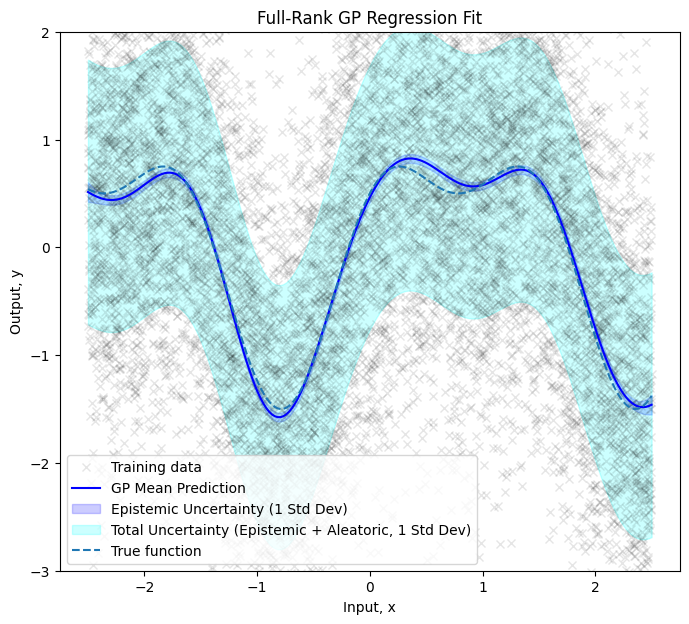

Time taken to fit full-rank GP with 10000 training points: 8.43 seconds


In [10]:
# Fit a full-rank GP with fixed hyperparameters with fixed lengthscale 0.57, variance 0.9, and noise variance 1.
lengthscale = 0.57
variance = 0.9
noise_var = 1.5

start_time = time.time()
plot_exact_gp_fit(large_full_X_train, large_full_y_train, X_grid, f_grid, lengthscale, variance, noise_var, training_data_opacity=0.1) # There's a lot of points which makes it hard to see the fit.
jax.random.normal(rng_key).block_until_ready() # Hopefully deal with any asynchronous dispatch issues that might mess with our timing. Note that we are not using JIT here, but if you decide to do so, you should make sure that your timings are for the actual computations and not the compilation. If in doubt, don't use JIT in this coursework.
end_time = time.time()
print(f"Time taken to fit full-rank GP with {large_n_train} training points: {end_time - start_time:.2f} seconds")

That's a substantial run time for a single fit, and we were cheating by not optimising the hyperparameters (e.g. by optimising the marginal likleihood). Clearly fitting the full-rank / exact GP is impractical here, so let's try using inducing points instead. In this task, you will eventually implement a sparse variational GP regression model, but first let's see why we shouldn't just train an exact GP on a subset of the data.

#### <font color="red"> Fit an exact GP on a random subset (of size 40) of the training data, and plot the resulting fit. You should optimise your hyperparameters as before by maximising the marginal likelihood, starting from the same initial hyperparameter values as before (lengthscale 1.0, variance 1.0, noise variance 1.0). Note that the random subset should be fixed throughout this entire process (1 mark) </font>

Random subset — lengthscale: 0.2312, variance: 1.0196, noise var: 1.2299


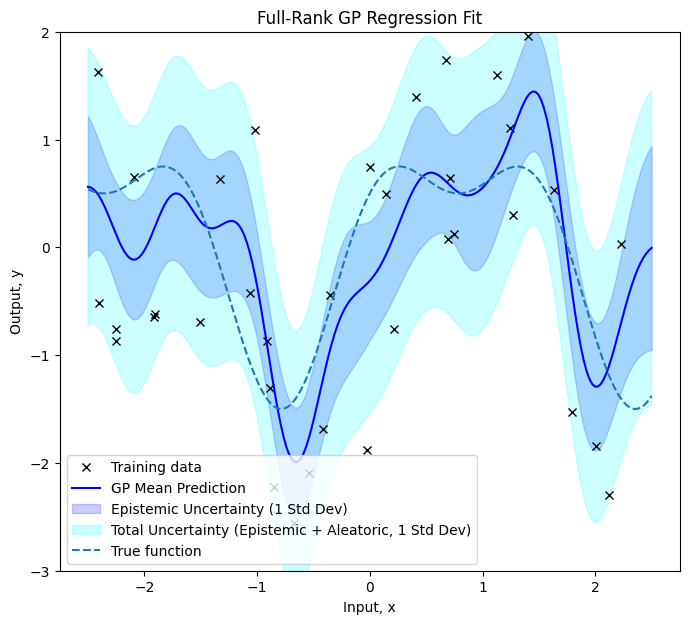

In [11]:
def fit_gp_hyperparams(X, y, num_iters=100, learning_rate=0.05):
    #Maximise the GP log marginal likelihood via Adam. Returns (lengthscale, variance, noise_var)
    params = {
        "log_lengthscale": jnp.array(0.0),
        "log_variance":    jnp.array(0.0),
        "log_noise_var":   jnp.array(0.0),
    }
    opt = optax.adam(learning_rate=learning_rate)
    opt_state = opt.init(params)
    for _ in range(num_iters):
        _, grad = jax.value_and_grad(
            lambda p: -gp_log_marginal_likelihood(
                X, y,
                jnp.exp(p["log_lengthscale"]), jnp.exp(p["log_variance"]), jnp.exp(p["log_noise_var"])
            )
        )(params)
        updates, opt_state = opt.update(grad, opt_state)
        params = optax.apply_updates(params, updates)
    return (
        float(jnp.exp(params["log_lengthscale"])),
        float(jnp.exp(params["log_variance"])),
        float(jnp.exp(params["log_noise_var"])),
    )

# Fix a random subset of 40 points
rng_key, rng_subkey = jax.random.split(rng_key)
subset_indices = jax.random.choice(rng_subkey, large_n_train, shape=(40,), replace=False)
X_subset_random = large_full_X_train[subset_indices]
y_subset_random = large_full_y_train[subset_indices]

final_ls_r, final_var_r, final_nv_r = fit_gp_hyperparams(X_subset_random, y_subset_random)

print(f"Random subset — lengthscale: {final_ls_r:.4f}, variance: {final_var_r:.4f}, noise var: {final_nv_r:.4f}")

plot_exact_gp_fit(X_subset_random, y_subset_random, X_grid, f_grid, final_ls_r, final_var_r, final_nv_r)



You probably observed that the fit is very poor, not really capturing our underlying function at all, because the data is so noisy. Ideally, we'd like the subset of data to track the shape of the underlying function. However, remember that in practice we don't actually know the underlying function (that's the whole point of doing regression), so cherry-picking a nice subset of data is difficult. But maybe we can do better than random selection by using a clustering algorithm to "summarise" the data slightly more intelligently?

#### <font color="red"> Select the 40 datapoint subset using k-means clustering and repeat the GP fitting (1 mark) </font>

K-means subset — lengthscale: 0.6445, variance: 0.3502, noise var: 1.2124


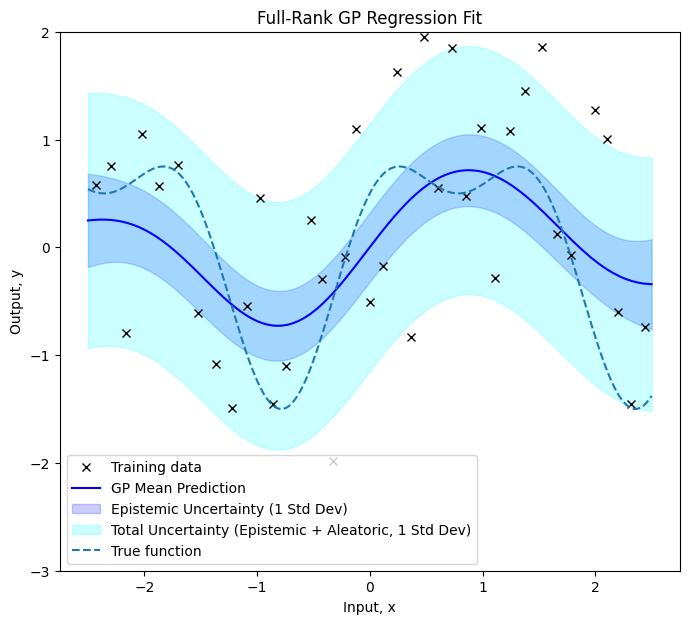

In [12]:
#### **** YOUR CODE HERE **** ####
kmeans = KMeans(n_clusters=40, random_state=0, n_init='auto').fit(np.array(large_full_X_train).reshape(-1, 1))
cluster_centres = jnp.array(kmeans.cluster_centers_.flatten())

# For each cluster centre, pick the training point closest to it as the subset point
# For each cluster centre, pick the nearest actual training point
distances = jnp.abs(large_full_X_train[:, None] - cluster_centres[None, :])
closest_indices = jnp.argmin(distances, axis=0)
X_subset_kmeans = large_full_X_train[closest_indices]
y_subset_kmeans = large_full_y_train[closest_indices]


final_ls_k, final_var_k, final_nv_k = fit_gp_hyperparams(X_subset_kmeans, y_subset_kmeans)

print(f"K-means subset — lengthscale: {final_ls_k:.4f}, variance: {final_var_k:.4f}, noise var: {final_nv_k:.4f}")

plot_exact_gp_fit(X_subset_kmeans, y_subset_kmeans, X_grid, f_grid, final_ls_k, final_var_k, final_nv_k)

You should have found that you could recover the shape of the function better with the k-means selected subset, but the uncertainty estimates were in some way poor (depending on how you implemented it, you probably either heavily underestimated the aleatoric uncertainty, or heavily overestimated the epistemic uncertainty compared to the exact full-dataset GP). Furthermore, this method might not work so well with more complicated functions data distributions. Perhaps most importantly from a Bayesian perspective, this method does not give a principled estimate of the posterior distribution — it is just a heuristic.

# Task 2: Sparse Variational Gaussian Process Regression
**24 marks for this task in total.**

In this task, you will implement the sparse variational Gaussian process regression model from Lecture 23. This uses a variational approximate posterior that depends on a number of inducing points which summarise the data, but since we're using variational inference, we get a principled lower bound on the marginal likelihood / evidence (the ELBO) and therefore a princpled approximation to our true posterior over function.

**Note: In order to achieve full marks in this task, you will need to utilise the practical tips presented in Lectures 22 and 23 (whitened parametrisation, solves instead of inverses, log-determinants using the Cholesky decomposition, diagonal-only computations where appropriate), to produce more numerically stable code and easier to optimise objectives.**

## <font color="red"> Task 2a </font>
<font color="red"> *8 marks overall* </font>

#### <font color="red"> Write the "prediction" algorithm for sparse variational GPs, that is, given a multivariate Gaussian variational distribution (mean and covariance) over the inducing points, and given some hyperparameters, output the predictive distribution for given test inputs (6 marks) </font>

**Note:** You should take in the variational parameters and hyperparameters as a `params` dictionary (or whatever you wish to name it) as before, because in subsequent tasks you will need to fit your approximate posterior using gradient ascent on the ELBO. You should have both the option to compute the full predictive test covariance matrix, or just the diagonal (i.e. the predictive variances) for situations where we don't need the covariances (e.g. when we are not sampling from the predictive distribution, but just want to plot error bars), to reduce the time and storage complexity.

**Hint:** The approximate posterior covariance matrix must be positive definite, but as with positive scalars, optax does not know about this constraint, so your learnable parameters will all be unconstrained. Hence it is recommended you learn a Cholesky factor $\mathbf L$ such that $\boldsymbol \Sigma_\text{ii} = \mathbf L \mathbf L^\top$. Note that Cholesky factors are lower triangular, with the diagonal entries all positive, so you will probably need 2 unconstrained parameter vectors, one for the diagonal entries (which must be positive), and one for the strictly lower triangular entries, and some code to reconstruct the Cholesky factor and / or the inducing covariance matrix from these parameters.

In [13]:
#### **** YOUR CODE HERE **** ####
def build_var_chol(var_chol_log_diag, var_chol_lower, M):
    L_v = jnp.zeros((M, M))
    # Fill strictly lower triangular entries
    lower_idx = jnp.tril_indices(M, k=-1)
    L_v = L_v.at[lower_idx].set(var_chol_lower)
    # Fill diagonal with exp to enforce positivity
    diag_idx = jnp.diag_indices(M)
    L_v = L_v.at[diag_idx].set(jnp.exp(var_chol_log_diag))
    return L_v


def svgp_predict(params, X_test, full_cov=False):
    ls  = jnp.exp(params["log_lengthscale"])
    var = jnp.exp(params["log_variance"])

    X_i = params["inducing_inputs"]   # (M,)
    m   = params["variational_mean"]  # (M,)
    M   = X_i.shape[0]

    L_v = build_var_chol(params["var_chol_log_diag"], params["var_chol_lower"], M)

    # Prior covariance over inducing points and its Cholesky
    K_ii = rbf_kernel(X_i, X_i, ls, var)          # (M, M)
    L_ii = stable_cholesky(K_ii)                   # (M, M)

    # Cross-covariance inducing → test: K_{i*}  shape (M, N_test)
    K_i_star = rbf_kernel(X_i, X_test, ls, var)   # (M, N_test)

    # alpha = L_ii^{-1} K_{i*}  via forward triangular solve  shape (M, N_test)
    alpha = jsp.linalg.solve_triangular(L_ii, K_i_star, lower=True)

    # Predictive mean:  mu_* = alpha^T m
    mu = alpha.T @ m   # (N_test,)

    # Whitened covariance contribution:  B = L_v^T alpha  shape (M, N_test)
    B = L_v.T @ alpha  # (M, N_test)

    if full_cov:
        K_star_star = rbf_kernel(X_test, X_test, ls, var)   # (N_test, N_test)
        cov = K_star_star - alpha.T @ alpha + B.T @ B
    else:
        # Diagonal only — avoids O(N_test^2) computation
        k_star_diag = rbf_kernel(X_test, X_test, ls, var, diag=True)   # (N_test,)
        cov = k_star_diag - jnp.sum(alpha**2, axis=0) + jnp.sum(B**2, axis=0)

    return mu, cov


#### <font color="red"> Initialise the variational parameters and hyperparameters in some sensible way, and plot the resulting fit (i.e. predict the function value on the grid of input) (2 marks) </font>
It is recommended you have a way to change the number of inducing points used. Note that the fit will likely be poor. Full marks will be awarded for initialising the variational mean in some way that uses the training data rather than just randomly / at zero.

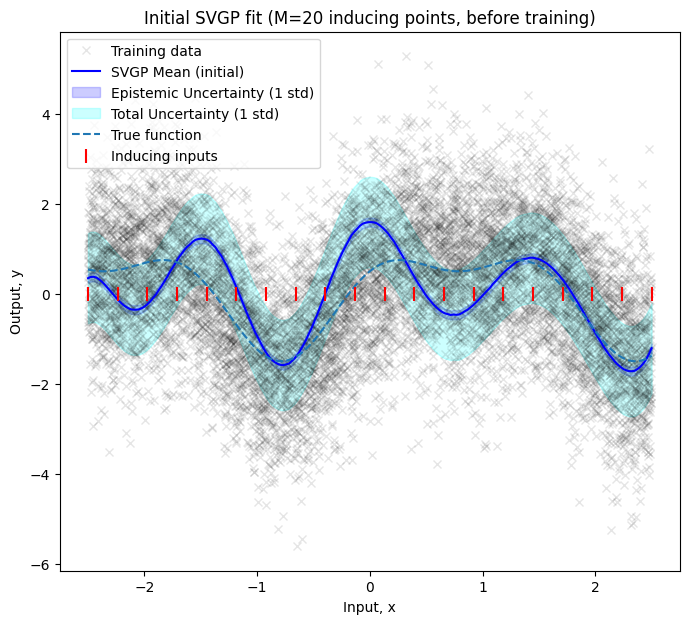

In [14]:
#### **** YOUR CODE HERE **** ####
def init_svgp_params(X_train, y_train, num_inducing=20, rng_key=None):
    M = num_inducing
    # Evenly spaced inducing inputs across data range
    X_i = jnp.linspace(X_train.min(), X_train.max(), M)

    # Sensible variational mean: interpolate training targets at inducing locations
    # Find the nearest training point to each inducing input
    dists = jnp.abs(X_train[:, None] - X_i[None, :])   # (N, M)
    nearest_idx = jnp.argmin(dists, axis=0)             # (M,)
    y_approx = y_train[nearest_idx]                     # (M,)

    # Un-whiten: m = L_ii^{-1} y_approx  so that  mu_i = L_ii m ≈ y_approx
    ls_init  = 1.0
    var_init = 1.0
    K_ii_init = rbf_kernel(X_i, X_i, ls_init, var_init)
    L_ii_init = stable_cholesky(K_ii_init)
    m_init = jsp.linalg.solve_triangular(L_ii_init, y_approx, lower=True)

    # Small diagonal L_v  →  S ≈ 0.01 I  (near-prior, avoids overconfident start)
    var_chol_log_diag_init = jnp.full((M,), jnp.log(0.1))
    num_lower = M * (M - 1) // 2
    var_chol_lower_init = jnp.zeros((num_lower,))

    return {
        "log_lengthscale":   jnp.array(0.0),
        "log_variance":      jnp.array(0.0),
        "log_noise_var":     jnp.array(0.0),
        "inducing_inputs":   X_i,
        "variational_mean":  m_init,
        "var_chol_log_diag": var_chol_log_diag_init,
        "var_chol_lower":    var_chol_lower_init,
    }


num_inducing = 20
svgp_params = init_svgp_params(large_full_X_train, large_full_y_train, num_inducing=num_inducing)

# Plot initial SVGP fit on the grid
mu_init, var_init_pred = svgp_predict(svgp_params, X_grid)
std_init = jnp.sqrt(jnp.clip(var_init_pred, 0.0))
noise_std_init = jnp.exp(0.5 * svgp_params["log_noise_var"])

plt.figure(figsize=(8, 7))
plt.plot(large_full_X_train, large_full_y_train, 'kx', alpha=0.1, label='Training data')
plt.plot(X_grid, mu_init, 'b', label='SVGP Mean (initial)')
plt.fill_between(X_grid, mu_init - std_init, mu_init + std_init,
                 color='blue', alpha=0.2, label='Epistemic Uncertainty (1 std)')
plt.fill_between(X_grid, mu_init - jnp.sqrt(std_init**2 + noise_std_init**2),
                 mu_init + jnp.sqrt(std_init**2 + noise_std_init**2),
                 color='cyan', alpha=0.2, label='Total Uncertainty (1 std)')
plt.plot(X_grid, f_grid, '--', label='True function')
plt.scatter(svgp_params["inducing_inputs"], jnp.zeros(num_inducing),
            marker='|', s=100, color='red', zorder=5, label='Inducing inputs')
plt.xlabel('Input, x')
plt.ylabel('Output, y')
plt.title(f'Initial SVGP fit (M={num_inducing} inducing points, before training)')
plt.legend()
plt.show()

## <font color="red"> Task 2b </font>
<font color="red"> *4 marks overall* </font>

#### <font color="red"> Derive the closed-form expected log-likelihood for the Gaussian likelihood. You should give your answer in LaTeX in the box provided below. (3 marks) </font>
In Lecture 23, we identify the expected log-likelihood as
$$\mathbb E_{q(\mathbf f_\text{t}; \boldsymbol \theta)} [\log p(\mathbf y_t | \mathbf f_\text{t})]$$
where $\mathbf y_t \in \mathbb R^N$ is our vector of training targets, and $q(\mathbf f_\text{t}; \boldsymbol \theta)$ is our marginal approximate posterior over the training function values, dependent on variational parameters $\boldsymbol \theta = \{\boldsymbol \mu_\text{i}, \boldsymbol \Sigma_\text{ii}\}$.

Derive the closed-form expression for this expected log-likelihood (full dataset) when the likelihood is Gaussian, i.e.
$$p(\mathbf y_t | \mathbf f_\text{t}) = \mathcal N(\mathbf y_t; \mathbf f_\text{t}, \sigma^2_\text{noise} \mathbf I).$$

It is recommended you use the notation $\mathbf y_t \in \mathbb R^N$ for the whole dataset, and $y_n$ for the individual target values $n=1,\ldots,N$. Similarly, use $\mathbf f_\text{t} \in \mathbb R^N$ for the whole vector of training function values, and $f_n$ or $f(\mathbf x_n)$ for the function values at invidual training inputs $\mathbf x_n$.


 Since the likelihood factorises over datapoints, the expected log-likelihood is a sum over $n$:
 $$\mathbb{E}_{q(\mathbf{f}_t;\boldsymbol\theta)}\left[\log p(\mathbf{y}_t \mid \mathbf{f}_t)\right] = \sum_{n=1}^{N} \mathbb{E}_{q(f_n;\boldsymbol\theta)}\left[\log p(y_n \mid f_n)\right]$$
 For each term, using $p(y_n \mid f_n) = \mathcal{N}(y_n;\, f_n,\, \sigma^2_\text{noise})$:
 $$\mathbb{E}_{q(f_n)}\left[\log p(y_n \mid f_n)\right] = -\frac{1}{2}\log(2\pi\sigma^2_\text{noise}) - \frac{1}{2\sigma^2_\text{noise}}\,\mathbb{E}_{q(f_n)}\!\left[(y_n - f_n)^2\right]$$
The expectation of the squared residual under $q(f_n) = \mathcal{N}(f_n;\,\mu_n,\,\Sigma_{nn})$ expands as:
$$\mathbb{E}_{q(f_n)}\!\left[(y_n - f_n)^2\right] = (y_n - \mu_n)^2 + \Sigma_{nn}$$ where $\mu_n$ is the $n$-th element of $\boldsymbol\mu_{t|i} = K_{ti}K_{ii}^{-1}\boldsymbol\mu_i$ and $\Sigma_{nn} = \left[\boldsymbol\Sigma_{tt|ii}\right]_{nn}$$is the corresponding diagonal element of the marginal predictive covariance.
Substituting back and summing over $n$:
$$\mathbb{E}_{q(\mathbf{f}_t;\boldsymbol\theta)}\left[\log p(\mathbf{y}_t \mid \mathbf{f}_t)\right] = -\frac{N}{2}\log(2\pi\sigma^2_\text{noise}) - \frac{1}{2\sigma^2_\text{noise}}\left[\|\mathbf{y}_t - \boldsymbol\mu_{t|i}\|^2 + \mathrm{tr}(\boldsymbol\Sigma_{tt|ii})\right]$$

#### <font color="red">  Write down the minibatch form (1 mark) </font>

Write down the minibatch estimator for the expected log-likelihood derived above, when using a minibatch of size $B$.

Use the notation $y_b$ for the target values in the minibatch, and $f_b$ or $f(\mathbf x_b)$ for the function values at the inputs in the minibatch.

**Note: you may use either the closed-form expected log-likelihood or a Monte-Carlo estimator in your code (for example, if you cannot derive the closed-form expression, or just preference). You will not be penalised for using either method in your code.**

For a minibatch $\mathcal{B} = \{(\mathbf{x}_b, y_b)\}_{b=1}^{B}$ drawn uniformly from the $N$ training points, an unbiased estimator of the full ELL is obtained by scaling the per-point contributions:
$$\widehat{\mathrm{ELL}} = \frac{N}{B}\sum_{b=1}^{B}\left[-\frac{1}{2}\log(2\pi\sigma^2_\text{noise}) - \frac{1}{2\sigma^2_\text{noise}}\left[(y_b - \mu_b)^2 + \Sigma_{bb}\right]\right]$$
where $\mu_b$ and $\Sigma_{bb}$ are the predictive mean and variance of $q(f(\mathbf{x}_b);\boldsymbol\theta)$ at the minibatch input $\mathbf{x}_b$. The factor $N/B$ corrects for the fact that we are only summing over $B$ of the $N$ terms.

## <font color="red"> Task 2c </font>
<font color="red"> *7 marks overall* </font>

You now need to implement the Evidence Lower Bound (ELBO), which we will later use to fit our variational parameters and hyperparameters by gradient ascent. Recall that the ELBO consists of two terms, the KL divergence between the variational distribution and the prior, and the expected log-likelihood of the data under the variational distribution. Since our dataset is very large, it will be necessary to use minibatching to estimate the expected log-likelihood term, instead of computing it over the whole dataset every ELBO evaluation.

#### <font color="red"> Implement the minibatch estimated expected log-likelihood term of the ELBO, using either the closed-form expression you just derived or a Monte-Carlo estimator (2 marks) </font>

**Notes:**
- You will not be penalised for using either the closed-form expected log-likelihood or Monte-Carlo estimator, as long as your code produces the correct quantity.
- Your function will need to take in the `params` dictionary, a minibatch of data (inputs and targets), the total dataset size, and potentially an rng key as arguments, and output the estimated expected log-likelihood, and potentially the updated rng key.

In [15]:
#### **** YOUR CODE HERE **** ####
def svgp_expected_log_likelihood(params, X_batch, y_batch, N_total):
    noise_var = jnp.exp(params["log_noise_var"])
    B = X_batch.shape[0]

    # Predictive mean and diagonal variance at minibatch points
    mu_b, sigma_bb = svgp_predict(params, X_batch, full_cov=False)   # both shape (B,)

    per_point = -0.5 * jnp.log(2 * jnp.pi * noise_var) - \
                (0.5 / noise_var) * ((y_batch - mu_b)**2 + sigma_bb)

    return (N_total / B) * jnp.sum(per_point)

#### <font color="red"> Implement the KL divergence term of the ELBO (4 marks) </font>

**Note:** Your function will need to take in the `params` dictionary as an argument, and output the KL divergence between the variational distribution and the prior.

In [16]:
#### **** YOUR CODE HERE **** ####
def svgp_kl_divergence(params):
    m   = params["variational_mean"]         # (M,)
    M   = m.shape[0]
    L_v = build_var_chol(params["var_chol_log_diag"], params["var_chol_lower"], M)

    trace_S  = jnp.sum(L_v**2)                              # ||L_v||_F^2 = tr(L_v L_v^T)
    quad     = jnp.dot(m, m)                                # ||m||^2
    log_det_S = 2.0 * jnp.sum(params["var_chol_log_diag"])  # log|S| = 2 * sum log-diag(L_v)

    return 0.5 * (trace_S + quad - M - log_det_S)

#### <font color="red"> Write a function that computes the ELBO (1 mark) </font>

In [17]:
def svgp_elbo(params, X_batch, y_batch, N_total):
    ell = svgp_expected_log_likelihood(params, X_batch, y_batch, N_total)
    kl  = svgp_kl_divergence(params)
    return ell - kl

## <font color="red"> Task 2d </font>
<font color="red"> *5 marks overall* </font>

#### <font color="red"> Train your variational parameters and hyperparameters by optimising the ELBO using Optax. Plot the ELBO over time to ensure convergence, and plot your final model's fit on the data (5 marks) </font>

You should find that your epistemic uncertainty is much smaller than it was with the "subset of data" method, but your aleatoric uncertainty should still match the spread of the data. You may need to try different learning rates and numbers of iterations (or "epochs" i.e. passes through the whole dataset) to get a good fit. Your minibatching should not repeat data points until you have gone through the entire dataset.

If you try to fit the full-rank GP on this dataset (not part of this task), you will find that each iteration of the marginal likelihood optimisation takes a very long time, and so the entire process would take much longer than the sparse GP (and wouldn't even fit in memory if the dataset was even larger). With sparse GPs, you can scale to millions of datapoints without too much trouble.

Epoch   1/20  mean ELBO: -284285.74
Epoch   2/20  mean ELBO: -185225.76
Epoch   3/20  mean ELBO: -183957.42
Epoch   4/20  mean ELBO: -182514.86
Epoch   5/20  mean ELBO: -180927.84
Epoch   6/20  mean ELBO: -179292.13
Epoch   7/20  mean ELBO: -177572.70
Epoch   8/20  mean ELBO: -175855.98
Epoch   9/20  mean ELBO: -173960.68
Epoch  10/20  mean ELBO: -172282.95
Epoch  11/20  mean ELBO: -170188.74
Epoch  12/20  mean ELBO: -168078.50
Epoch  13/20  mean ELBO: -166336.22
Epoch  14/20  mean ELBO: -164331.85
Epoch  15/20  mean ELBO: -162199.85
Epoch  16/20  mean ELBO: -159885.57
Epoch  17/20  mean ELBO: -157888.50
Epoch  18/20  mean ELBO: -155505.64
Epoch  19/20  mean ELBO: -153373.09
Epoch  20/20  mean ELBO: -151143.86


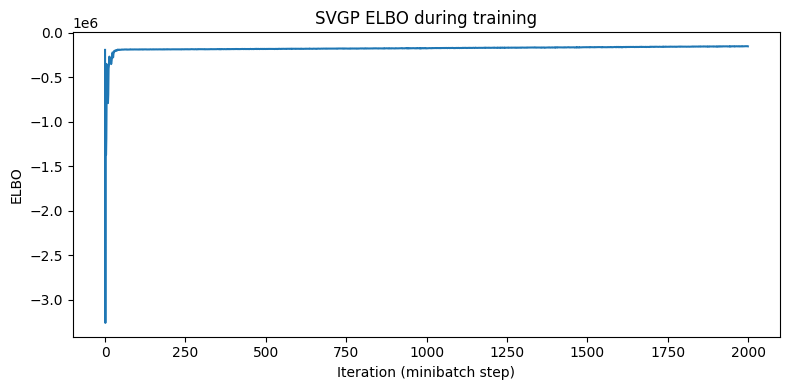

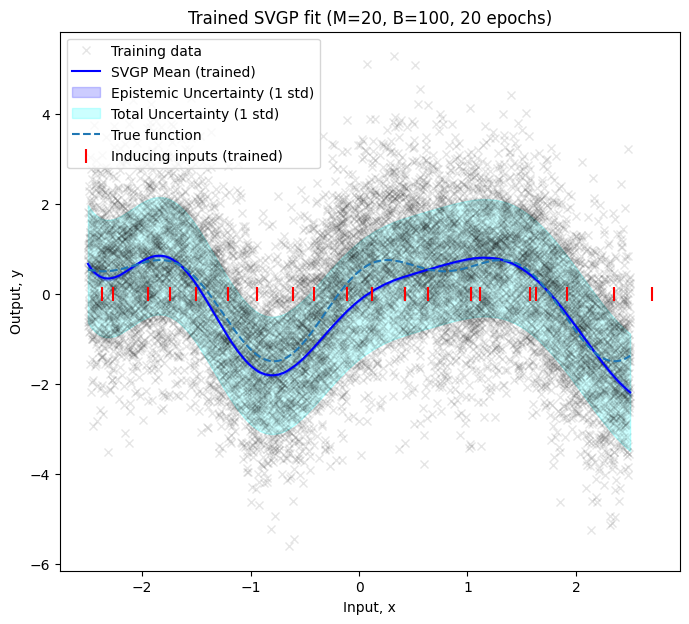

Trained hyperparams — lengthscale: 1.1094, variance: 0.2621, noise var: 1.7029


In [18]:
#### **** YOUR CODE HERE **** ####
num_inducing   = 20
batch_size     = 100
num_epochs     = 20
learning_rate  = 0.05

N_total = large_full_X_train.shape[0]

# Reinitialise params from Task 2a sensible initialisation
svgp_params = init_svgp_params(large_full_X_train, large_full_y_train,
                                num_inducing=num_inducing)

opt = optax.adam(learning_rate=learning_rate)
opt_state = opt.init(svgp_params)

elbo_history = []

for epoch in range(num_epochs):
    # Shuffle all indices without replacement — no repeats within an epoch
    rng_key, rng_subkey = jax.random.split(rng_key)
    perm = jax.random.permutation(rng_subkey, N_total)

    epoch_elbo = 0.0
    num_batches = 0

    for start in range(0, N_total, batch_size):
        batch_idx = perm[start : start + batch_size]
        X_batch = large_full_X_train[batch_idx]
        y_batch = large_full_y_train[batch_idx]

        neg_elbo_val, grads = jax.value_and_grad(
            lambda p: -svgp_elbo(p, X_batch, y_batch, N_total)
        )(svgp_params)

        updates, opt_state = opt.update(grads, opt_state)
        svgp_params = optax.apply_updates(svgp_params, updates)

        epoch_elbo += float(-neg_elbo_val)
        num_batches += 1
        elbo_history.append(float(-neg_elbo_val))

    print(f"Epoch {epoch+1:3d}/{num_epochs}  mean ELBO: {epoch_elbo / num_batches:.2f}")

# --- Plot 1: ELBO vs iteration ---
plt.figure(figsize=(8, 4))
plt.plot(elbo_history)
plt.xlabel('Iteration (minibatch step)')
plt.ylabel('ELBO')
plt.title('SVGP ELBO during training')
plt.tight_layout()
plt.show()

# --- Plot 2: Final SVGP fit ---
mu_final, var_final = svgp_predict(svgp_params, X_grid, full_cov=False)
std_final = jnp.sqrt(jnp.clip(var_final, 0.0))
noise_std_final = jnp.exp(0.5 * svgp_params["log_noise_var"])

plt.figure(figsize=(8, 7))
plt.plot(large_full_X_train, large_full_y_train, 'kx', alpha=0.1, label='Training data')
plt.plot(X_grid, mu_final, 'b', label='SVGP Mean (trained)')
plt.fill_between(X_grid, mu_final - std_final, mu_final + std_final,
                 color='blue', alpha=0.2, label='Epistemic Uncertainty (1 std)')
plt.fill_between(X_grid,
                 mu_final - jnp.sqrt(std_final**2 + noise_std_final**2),
                 mu_final + jnp.sqrt(std_final**2 + noise_std_final**2),
                 color='cyan', alpha=0.2, label='Total Uncertainty (1 std)')
plt.plot(X_grid, f_grid, '--', label='True function')
plt.scatter(svgp_params["inducing_inputs"], jnp.zeros(num_inducing),
            marker='|', s=100, color='red', zorder=5, label='Inducing inputs (trained)')
plt.xlabel('Input, x')
plt.ylabel('Output, y')
plt.title(f'Trained SVGP fit (M={num_inducing}, B={batch_size}, {num_epochs} epochs)')
plt.legend()
plt.show()

print(f"Trained hyperparams — lengthscale: {float(jnp.exp(svgp_params['log_lengthscale'])):.4f}, "
      f"variance: {float(jnp.exp(svgp_params['log_variance'])):.4f}, "
      f"noise var: {float(jnp.exp(svgp_params['log_noise_var'])):.4f}")


# Task 3: Sparse Variational Gaussian Process Classification
**5 marks for this task in total.**

We now consider an entirely different task, which is binary classification. We first create the dataset, a simple 2D dataset as we saw in the lecture, but with more noise to make the predicted probabilities less extreme.

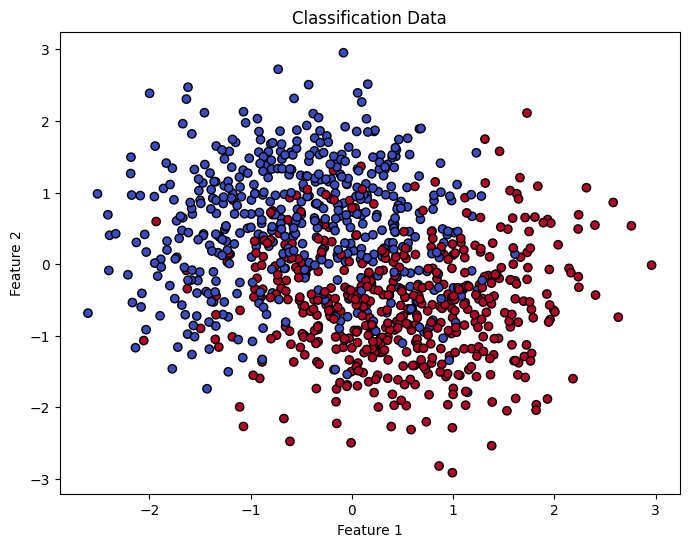

In [19]:
from sklearn.datasets import make_moons

def get_classification_data(n_samples=1000, noise=0.5, seed=42):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return jnp.array(X), jnp.array(y)

def make_grid(X, h=0.05):
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = jnp.meshgrid(jnp.arange(x1_min, x1_max, h), jnp.arange(y_min, y_max, h))
    grid_inputs = jnp.c_[xx1.ravel(), xx2.ravel()]
    return xx1, xx2, grid_inputs

X_train_classification, y_train_classification = get_classification_data()

# Plot the classification data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_classification[:, 0], X_train_classification[:, 1], c=y_train_classification, cmap='coolwarm', edgecolors='k')
plt.title('Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## <font color="red"> Task 3a </font>
<font color="red"> *5 marks overall* </font>

#### <font color="red"> Implement sparse variational Gaussian process classification using a Monte Carlo approximated Logistic-Bernoulli likelihood, and plot the resulting predicted probability surface, i.e. split the input space into a grid and colour each point according to the probabiilty of being in class 1 or 0. (4 marks) </font>

You should be able to largely reuse most of your code from the regression task.

**Plotting tip:**

We have provided the `make_grid` function to help you evaluate your model over a grid of input points. It automatically creates a regular 2d grid of points that covers the data (plus a margin around the outside). The parameter `h` controls the resolution of the grid. You can use it like so:
`xx1, xx2, grid_inputs = make_grid(X_train_classification)`

`grid_inputs` is a 2D array of shape `(num_grid_points, 2)` that you can feed into your model to get predictions

`xx1` and `xx2` are 2D arrays of shape `(num_grid_points_per_axis, num_grid_points_per_axis)` that you can use for plotting with `plt.contourf` like so:

`plt.contourf(xx1, xx2, grid_predictions.reshape(xx1.shape), levels=50, cmap='coolwarm')`

Here, `grid_predictions` is a 1D array of shape `(num_grid_points,)` that contains e.g. predicted probabilities, latent means, or latent stds.

Epoch   1/20  mean ELBO: -652.89
Epoch   2/20  mean ELBO: -506.89
Epoch   3/20  mean ELBO: -445.23
Epoch   4/20  mean ELBO: -433.47
Epoch   5/20  mean ELBO: -425.06
Epoch   6/20  mean ELBO: -427.69
Epoch   7/20  mean ELBO: -429.40
Epoch   8/20  mean ELBO: -421.23
Epoch   9/20  mean ELBO: -420.55
Epoch  10/20  mean ELBO: -422.95
Epoch  11/20  mean ELBO: -421.04
Epoch  12/20  mean ELBO: -420.94
Epoch  13/20  mean ELBO: -419.26
Epoch  14/20  mean ELBO: -419.10
Epoch  15/20  mean ELBO: -419.23
Epoch  16/20  mean ELBO: -424.35
Epoch  17/20  mean ELBO: -425.48
Epoch  18/20  mean ELBO: -422.82
Epoch  19/20  mean ELBO: -416.54
Epoch  20/20  mean ELBO: -421.40


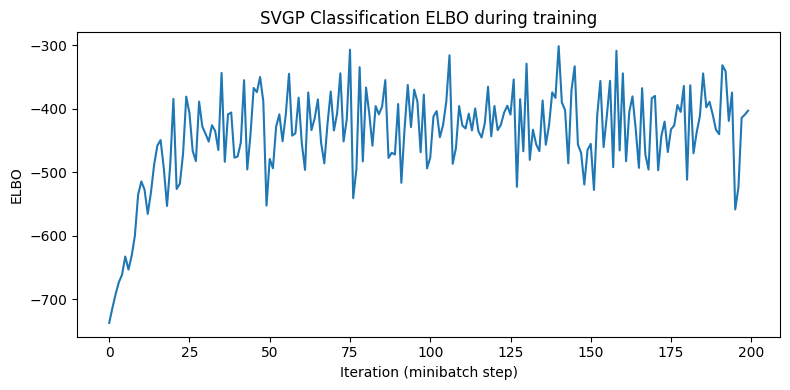

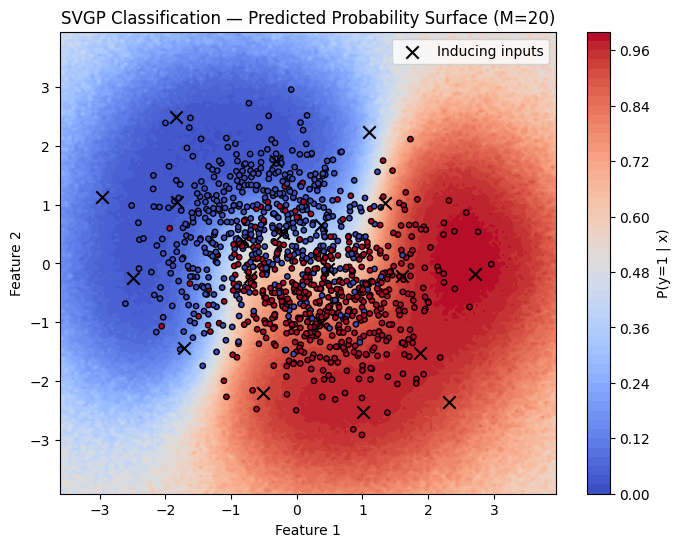

In [20]:
#### **** YOUR CODE HERE **** ####
def init_svgp_params_classification(X_train, num_inducing=20):
    M = num_inducing
    kmeans = KMeans(n_clusters=M, random_state=0, n_init='auto').fit(np.array(X_train))
    X_i = jnp.array(kmeans.cluster_centers_)   # (M, 2)

    m_init = jnp.zeros(M)

    var_chol_log_diag_init = jnp.full((M,), jnp.log(0.1))
    num_lower = M * (M - 1) // 2
    var_chol_lower_init = jnp.zeros((num_lower,))

    return {
        "log_lengthscale":   jnp.array(0.0),
        "log_variance":      jnp.array(0.0),
        "inducing_inputs":   X_i,
        "variational_mean":  m_init,
        "var_chol_log_diag": var_chol_log_diag_init,
        "var_chol_lower":    var_chol_lower_init,
    }


def svgp_ell_classification(params, X_batch, y_batch, N_total, rng_key, n_samples=10):
    B = X_batch.shape[0]
    mu_b, sigma_bb = svgp_predict(params, X_batch, full_cov=False)  # (B,), (B,)
    std_b = jnp.sqrt(jnp.clip(sigma_bb, 1e-6))                     # (B,)

    rng_key, rng_subkey = jax.random.split(rng_key)
    eps = jax.random.normal(rng_subkey, shape=(n_samples, B))       # (S, B)

    # Reparametrised samples: f^(s) = mu + std * eps   shape (S, B)
    f_samples = mu_b[None, :] + std_b[None, :] * eps

    # Log-Bernoulli likelihood via log-sigmoid for numerical stability
    # log p(y=1|f) = log sigma(f) = -softplus(-f)
    # log p(y=0|f) = log(1 - sigma(f)) = -softplus(f)
    log_sigma_f  = -jax.nn.softplus(-f_samples)   # (S, B)
    log_1msigma  = -jax.nn.softplus(f_samples)    # (S, B)

    y = y_batch[None, :].astype(jnp.float32)      # (1, B)
    log_lik = y * log_sigma_f + (1.0 - y) * log_1msigma   # (S, B)

    # Average over S samples, sum over B, scale by N/B
    ell = (N_total / B) * jnp.sum(jnp.mean(log_lik, axis=0))
    return ell, rng_key


def svgp_elbo_classification(params, X_batch, y_batch, N_total, rng_key, n_samples=10):
    ell, rng_key = svgp_ell_classification(params, X_batch, y_batch, N_total, rng_key, n_samples)
    kl = svgp_kl_divergence(params)
    return ell - kl, rng_key


# --- Training ---
num_inducing_c = 20
batch_size_c   = 100
num_epochs_c   = 20
lr_c           = 0.05
n_mc_samples   = 10

N_class = X_train_classification.shape[0]

cls_params = init_svgp_params_classification(X_train_classification, num_inducing=num_inducing_c)
opt_c = optax.adam(learning_rate=lr_c)
opt_state_c = opt_c.init(cls_params)

elbo_history_c = []

for epoch in range(num_epochs_c):
    rng_key, rng_subkey = jax.random.split(rng_key)
    perm = jax.random.permutation(rng_subkey, N_class)

    epoch_elbo = 0.0
    num_batches = 0

    for start in range(0, N_class, batch_size_c):
        batch_idx = perm[start : start + batch_size_c]
        X_batch = X_train_classification[batch_idx]
        y_batch = y_train_classification[batch_idx]
        
        # Advance the key each mini-batch so MC samples differ across steps
        rng_key, batch_key = jax.random.split(rng_key)

        def neg_elbo_fn(p):
            val, _ = svgp_elbo_classification(p, X_batch, y_batch, N_class, batch_key, n_mc_samples)
            return -val

        neg_val, grads = jax.value_and_grad(neg_elbo_fn)(cls_params)
        updates, opt_state_c = opt_c.update(grads, opt_state_c)
        cls_params = optax.apply_updates(cls_params, updates)

        epoch_elbo += float(-neg_val)
        num_batches += 1
        elbo_history_c.append(float(-neg_val))

    print(f"Epoch {epoch+1:3d}/{num_epochs_c}  mean ELBO: {epoch_elbo / num_batches:.2f}")

# --- Plot: ELBO ---
plt.figure(figsize=(8, 4))
plt.plot(elbo_history_c)
plt.xlabel('Iteration (minibatch step)')
plt.ylabel('ELBO')
plt.title('SVGP Classification ELBO during training')
plt.tight_layout()
plt.show()

# --- Plot: Predicted probability surface ---
xx1, xx2, grid_inputs = make_grid(X_train_classification)

mu_grid, sigma_grid = svgp_predict(cls_params, grid_inputs, full_cov=False)  # (G,), (G,)
std_grid = jnp.sqrt(jnp.clip(sigma_grid, 1e-6))

# MC predicted probability: E[sigma(f)] ≈ (1/S) sum_s sigma(mu + std * eps)
rng_key, rng_subkey = jax.random.split(rng_key)
eps_pred = jax.random.normal(rng_subkey, shape=(100, mu_grid.shape[0]))  # (S, G)
f_pred_samples = mu_grid[None, :] + std_grid[None, :] * eps_pred
prob_grid = jnp.mean(jax.nn.sigmoid(f_pred_samples), axis=0)             # (G,)

plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, np.array(prob_grid).reshape(xx1.shape), levels=50, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='P(y=1 | x)')
plt.scatter(X_train_classification[:, 0], X_train_classification[:, 1],
            c=y_train_classification, cmap='coolwarm', edgecolors='k', s=15, zorder=5)
plt.scatter(cls_params["inducing_inputs"][:, 0], cls_params["inducing_inputs"][:, 1],
            marker='x', color='black', s=80, zorder=6, label='Inducing inputs')
plt.title(f'SVGP Classification — Predicted Probability Surface (M={num_inducing_c})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#### <font color="red"> Plot the mean and standard deviation of the latent function across the input grid (1 mark) </font>

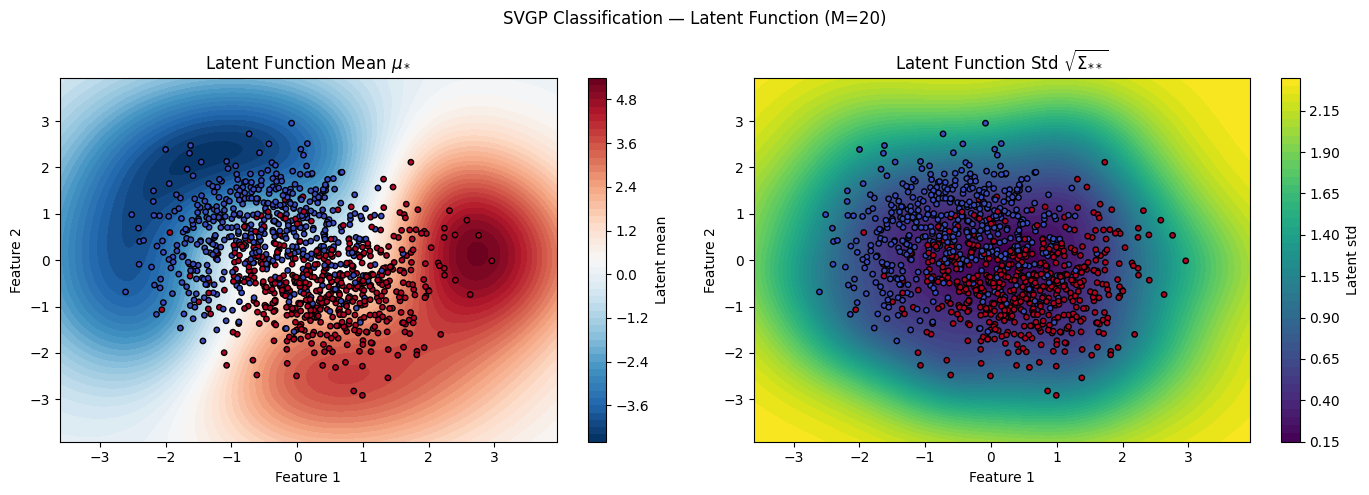

In [21]:
#### **** YOUR CODE HERE **** ####
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latent mean
cf1 = axes[0].contourf(xx1, xx2, np.array(mu_grid).reshape(xx1.shape), levels=50, cmap='RdBu_r')
fig.colorbar(cf1, ax=axes[0], label='Latent mean')
axes[0].scatter(X_train_classification[:, 0], X_train_classification[:, 1],
                c=y_train_classification, cmap='coolwarm', edgecolors='k', s=15, zorder=5)
axes[0].set_title('Latent Function Mean $\\mu_*$')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Latent std
cf2 = axes[1].contourf(xx1, xx2, np.array(std_grid).reshape(xx1.shape), levels=50, cmap='viridis')
fig.colorbar(cf2, ax=axes[1], label='Latent std')
axes[1].scatter(X_train_classification[:, 0], X_train_classification[:, 1],
                c=y_train_classification, cmap='coolwarm', edgecolors='k', s=15, zorder=5)
axes[1].set_title('Latent Function Std $\\sqrt{\\Sigma_{**}}$')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.suptitle(f'SVGP Classification — Latent Function (M={num_inducing_c})')
plt.tight_layout()
plt.show()